# Thesis Part 2
## ViT + Adapter Modules (Frozen Backbone) in TIL CL environmnet
### What this notebook does:
- Freezes the entire ViT-Tiny backbone (no backbone weights are updated)
- Inserts lightweight bottleneck adapter modules inside each transformer block
- Only adapter weights are trained per task
- Compares against the baseline ViT and ResNet results from Notebook 1

### Adapter architecture (per transformer block):
```
LayerNorm → Linear (192→64) → GELU → Linear (64→192)
```
**Fixes applied over v1:**
- set the seed
-  convert the labels inside the loop

## Summary

This experiment evaluates adapter-based parameter-efficient fine-tuning for
CL with Vision Transformers.

By freezing the backbone and training only lightweight adapter modules,
the approach aims to reduce catastrophic forgetting while maintaining
performance across tasks.

In [ ]:
!pip install timm -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
import random

def set_seed(seed=42):
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Seed set to {seed}')

set_seed(42)

Seed set to 42


## Data Preparation
Same as Baseline Notebook 1-5 tasks 20 classes each with ImageNet normalization.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset = datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

NUM_TASKS        = 5
CLASSES_PER_TASK = 100 // NUM_TASKS  # 20

def create_tasks(dataset, num_tasks=NUM_TASKS):
    tasks = []
    classes_per_task = []
    targets = np.array(dataset.targets)
    for i in range(num_tasks):
        class_range = list(range(i * CLASSES_PER_TASK, (i + 1) * CLASSES_PER_TASK))
        idx = np.isin(targets, class_range).nonzero()[0]
        tasks.append(Subset(dataset, idx))
        classes_per_task.append(class_range)
    return tasks, classes_per_task

train_tasks, classes_per_task = create_tasks(train_dataset)
test_tasks,  _                = create_tasks(test_dataset)

print(f'Tasks: {NUM_TASKS}, Classes per task: {CLASSES_PER_TASK}')
print(f'Train samples per task: {len(train_tasks[0])}')

100%|██████████| 169M/169M [00:05<00:00, 28.8MB/s]


Tasks: 5, Classes per task: 20
Train samples per task: 10000


## Adapter Module

A bottleneck adapter has three components:
1. **Down-projection**: reduces dimension from `d_model` (768) to `bottleneck_dim` (64)
2. **Non-linearity**: GELU activation
3. **Up-projection**: restores dimension back to `d_model` (768)
4. **Residual connection**: adds the adapter output to its input so the frozen block output is preserved

Which means if the adapter weights are initialised near zero, the adapter starts as an identity function and it doesn't disrupt the pretrained ViT at all at the start of training.

In [ ]:
class AdapterModule(nn.Module):
    """
    Bottleneck adapter inserted after each transformer block.
    Architecture: LayerNorm -> Linear(d->b) -> GELU -> Linear(b->d) -> residual
    """
    def __init__(self, d_model=192, bottleneck_dim=64):
        super().__init__()
        self.norm       = nn.LayerNorm(d_model)
        self.down_proj  = nn.Linear(d_model, bottleneck_dim)
        self.activation = nn.GELU()
        self.up_proj    = nn.Linear(bottleneck_dim, d_model)

        # Initialise near zero so adapter starts as identity
        nn.init.zeros_(self.up_proj.weight)
        nn.init.zeros_(self.up_proj.bias)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        residual = x
        x = self.norm(x)
        x = self.down_proj(x)
        x = self.activation(x)
        x = self.up_proj(x)
        return x + residual  # residual connection

## ViT with Adapters

Wrap the ViT-Tiny model by:
1. Loading pretrained ViT-Tiny (d_model=192, 12 transformer blocks)
2. **Freezing all backbone parameters**
3. Inserting one AdapterModule after each of the 12 transformer blocks
4. Keeping the classification head trainable

Only adapter weights + classification head are updated during training.

In [ ]:
class ViTWithAdapters(nn.Module):
    """
    ViT-Tiny with frozen backbone and trainable adapter modules.
    One adapter is inserted after each transformer block.
    """
    def __init__(self, num_classes=100, bottleneck_dim=64):
        super().__init__()

        # Load pretrained ViT-Tiny
        # vit_tiny_patch16_224: d_model=192, 12 blocks, patch_size=16
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=True,
            num_classes=num_classes
        )

        # Step 1: Freeze ALL backbone parameters
        for param in self.vit.parameters():
            param.requires_grad = False

        # Step 2: Unfreeze only the classification head
        for param in self.vit.head.parameters():
            param.requires_grad = True

        # Step 3: Insert one adapter after each transformer block
        d_model = self.vit.embed_dim  # 192 for vit_tiny
        num_blocks = len(self.vit.blocks)
        self.adapters = nn.ModuleList([
            AdapterModule(d_model=d_model, bottleneck_dim=bottleneck_dim)
            for _ in range(num_blocks)
        ])

        print(f'ViT backbone frozen. Blocks: {num_blocks}, d_model: {d_model}')
        self._print_param_counts()

    def _print_param_counts(self):
        total       = sum(p.numel() for p in self.parameters())
        trainable   = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen      = total - trainable
        print(f'Total params    : {total:,}')
        print(f'Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)')
        print(f'Frozen params   : {frozen:,}  ({100*frozen/total:.1f}%)')

    def forward(self, x):
        # Patch embedding + positional encoding (frozen)
        x = self.vit.patch_embed(x)
        x = self.vit._pos_embed(x)
        x = self.vit.patch_drop(x)
        x = self.vit.norm_pre(x)

        # Pass through each transformer block + its adapter
        for i, block in enumerate(self.vit.blocks):
            x = block(x)              # frozen transformer block
            x = self.adapters[i](x)   # trainable adapter

        x = self.vit.norm(x)          # final layer norm (frozen)
        x = self.vit.forward_head(x)  # classification head (trainable)
        return x

## Training and Evaluation Functions
Same as baseline notebook 1 only trainable parameters are updated by the optimizer.

In [ ]:
def train_model(model, train_data, epochs=10, lr=1e-3):
    """Train only the trainable parameters (adapters + head)."""
    model.train()
    # Only pass trainable params to optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer  = optim.Adam(trainable_params, lr=lr)
    criterion  = nn.CrossEntropyLoss()
    dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)

    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'  Epoch {epoch+1}/{epochs} — Loss: {running_loss / len(dataloader):.4f}')


def evaluate_task(model, task_data, task_classes):
    """TIL evaluation: task-masked logits."""
    model.eval()
    correct, total = 0, 0
    dataloader = DataLoader(task_data, batch_size=64, num_workers=2)
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs      = model(images)
            outputs_task = outputs[:, task_classes]
            # Vectorised label mapping: faster than list .index() loop
            label_map = torch.full((100,), -1, dtype=torch.long)
            for local_idx, global_idx in enumerate(task_classes):
                label_map[global_idx] = local_idx
            labels_local = label_map[labels.cpu()].to(device)
            _, preds = torch.max(outputs_task, 1)
            correct += (preds == labels_local).sum().item()
            total   += labels.size(0)
    return correct / total * 100


def evaluate_all_tasks(model, test_tasks, classes_per_task, num_seen):
    """Evaluate on all tasks seen so far."""
    return [
        evaluate_task(model, test_tasks[t], classes_per_task[t])
        for t in range(num_seen)
    ]

## Metrics
Same metrics as baseline Notebook 1 for direct comparison.

In [ ]:
def compute_metrics(acc_matrix):
    T    = len(acc_matrix)
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]

    # Average Accuracy
    avg_acc = np.nanmean(full[T - 1])

    # Per-task Forgetting and average
    forgetting = []
    for i in range(T - 1):
        max_acc   = np.nanmax(full[:, i])
        final_acc = full[T - 1][i]
        forgetting.append(max_acc - final_acc)
    f_avg = np.mean(forgetting)

    # Backward Transfer
    bwt = np.mean([full[T-1][i] - full[i][i] for i in range(T - 1)])

    return avg_acc, f_avg, bwt, forgetting

## Running ViT + Adapters (Frozen Backbone)

In [ ]:
# Build model
vit_adapter = ViTWithAdapters(num_classes=100, bottleneck_dim=64).to(device)

adapter_acc_matrix = []

for t_id in range(NUM_TASKS):
    print(f'\n--- ViT+Adapters: Training on Task {t_id + 1}/{NUM_TASKS} ---')
    train_model(vit_adapter, train_tasks[t_id], epochs=10, lr=1e-3)

    accs = evaluate_all_tasks(vit_adapter, test_tasks, classes_per_task, num_seen=t_id + 1)
    adapter_acc_matrix.append(accs)
    print(f'  Accuracies after Task {t_id + 1}: {[f"{a:.2f}" for a in accs]}')

adapter_avg_acc, adapter_f_avg, adapter_bwt, adapter_forgetting = compute_metrics(adapter_acc_matrix)

print('\n=== ViT + Adapters Final Results ===')
print(f'  Average Accuracy  : {adapter_avg_acc:.2f}%')
print(f'  Average Forgetting: {adapter_f_avg:.2f}%')
print(f'  Backward Transfer : {adapter_bwt:.2f}%')
print(f'  Per-task Forgetting: {[f"{f:.2f}" for f in adapter_forgetting]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT backbone frozen. Blocks: 12, d_model: 192
Total params    : 5,846,308
Trainable params: 321,892  (5.5%)
Frozen params   : 5,524,416  (94.5%)

--- ViT+Adapters: Training on Task 1/5 ---
  Epoch 1/10 — Loss: 0.6691
  Epoch 2/10 — Loss: 0.1711
  Epoch 3/10 — Loss: 0.0911
  Epoch 4/10 — Loss: 0.0658
  Epoch 5/10 — Loss: 0.0528
  Epoch 6/10 — Loss: 0.0383
  Epoch 7/10 — Loss: 0.0223
  Epoch 8/10 — Loss: 0.0493
  Epoch 9/10 — Loss: 0.0475
  Epoch 10/10 — Loss: 0.0171
  Accuracies after Task 1: ['92.70']

--- ViT+Adapters: Training on Task 2/5 ---
  Epoch 1/10 — Loss: 0.8618
  Epoch 2/10 — Loss: 0.1153
  Epoch 3/10 — Loss: 0.0453
  Epoch 4/10 — Loss: 0.0239
  Epoch 5/10 — Loss: 0.0279
  Epoch 6/10 — Loss: 0.0237
  Epoch 7/10 — Loss: 0.0126
  Epoch 8/10 — Loss: 0.0166
  Epoch 9/10 — Loss: 0.0244
  Epoch 10/10 — Loss: 0.0292
  Accuracies after Task 2: ['83.30', '92.25']

--- ViT+Adapters: Training on Task 3/5 ---
  Epoch 1/10 — Loss: 0.9049
  Epoch 2/10 — Loss: 0.1647
  Epoch 3/10 — Loss: 0

## Comparison Table
Comparison with Baseline notebook 1 results.

In [ ]:
# Baseline Notebook 1 results
resnet_avg_acc  = 24.22;  resnet_f_avg  = 69.17;  resnet_bwt  = -69.17
vit_avg_acc     = 41.91;  vit_f_avg     = 63.26;  vit_bwt     = -63.26


print('\n' + '='*65)
print(f'{"Metric":<30} {"ResNet-18":>10} {"ViT-Tiny":>10} {"ViT+Adapt":>10}')
print('='*65)
print(f'{"Average Accuracy (%)":<30} {resnet_avg_acc:>10.2f} {vit_avg_acc:>10.2f} {adapter_avg_acc:>10.2f}')
print(f'{"Average Forgetting (%)":<30} {resnet_f_avg:>10.2f} {vit_f_avg:>10.2f} {adapter_f_avg:>10.2f}')
print(f'{"Backward Transfer (%)":<30} {resnet_bwt:>10.2f} {vit_bwt:>10.2f} {adapter_bwt:>10.2f}')
print('='*65)


Metric                          ResNet-18   ViT-Tiny  ViT+Adapt
Average Accuracy (%)                24.22      41.91      76.93
Average Forgetting (%)              69.17      63.26      19.91
Backward Transfer (%)              -69.17     -63.26     -19.91


## Visualisation

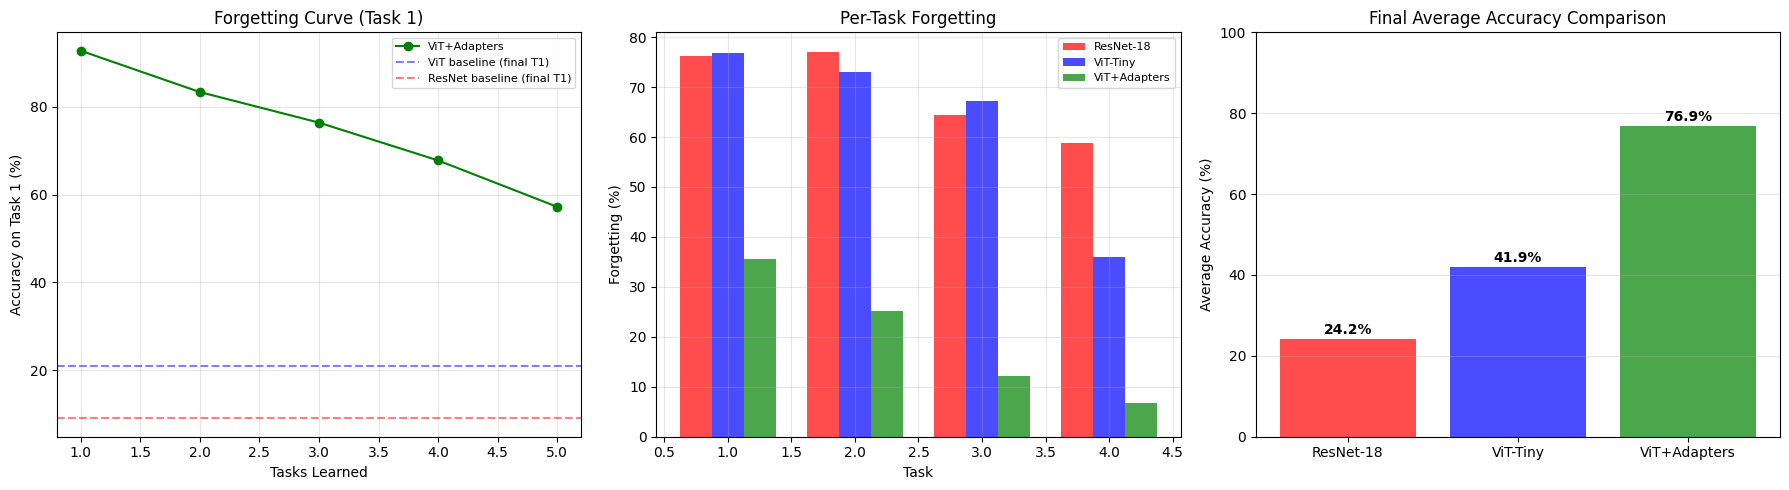

Figure saved as adapter_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Task 1 forgetting curve
ax = axes[0]
adapter_task1 = [adapter_acc_matrix[t][0] for t in range(NUM_TASKS)]
ax.plot(range(1, NUM_TASKS + 1), adapter_task1, 'g-o', label='ViT+Adapters')
# Baseline reference lines from Notebook 1 results
ax.axhline(y=20.90, color='b', linestyle='--', alpha=0.5, label='ViT baseline (final T1)')
ax.axhline(y=9.10,  color='r', linestyle='--', alpha=0.5, label='ResNet baseline (final T1)')
ax.set_xlabel('Tasks Learned')
ax.set_ylabel('Accuracy on Task 1 (%)')
ax.set_title('Forgetting Curve (Task 1)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Per-task forgetting bar chart
ax = axes[1]
x     = np.arange(1, NUM_TASKS)
width = 0.25
resnet_forg  = [76.30, 77.10, 64.50, 58.80]  # from Notebook 1
vit_forg     = [76.80, 73.10, 67.20, 35.95]  # from Notebook 1
ax.bar(x - width, resnet_forg,         width, label='ResNet-18',    color='red',   alpha=0.7)
ax.bar(x,         vit_forg,            width, label='ViT-Tiny',     color='blue',  alpha=0.7)
ax.bar(x + width, adapter_forgetting,  width, label='ViT+Adapters', color='green', alpha=0.7)
ax.set_xlabel('Task')
ax.set_ylabel('Forgetting (%)')
ax.set_title('Per-Task Forgetting')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Average accuracy bar chart (final comparison)
ax = axes[2]
models  = ['ResNet-18', 'ViT-Tiny', 'ViT+Adapters']
avg_accs = [resnet_avg_acc, vit_avg_acc, adapter_avg_acc]
colors   = ['red', 'blue', 'green']
bars = ax.bar(models, avg_accs, color=colors, alpha=0.7)
for bar, val in zip(bars, avg_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Final Average Accuracy Comparison')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('adapter_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as adapter_results.png')

## Accuracy Matrix Heatmap

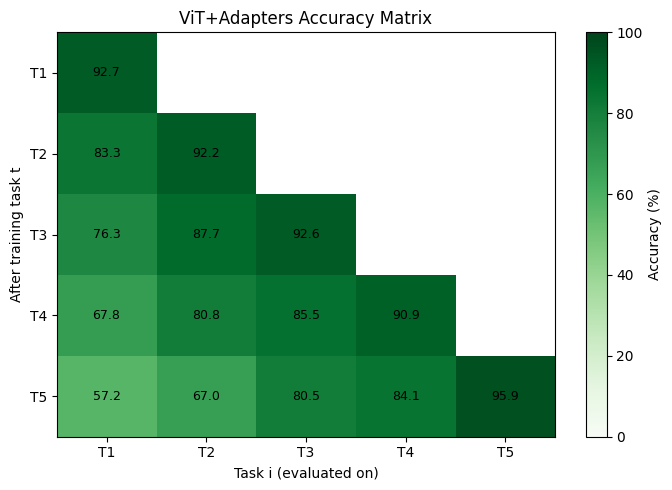

Figure saved as adapter_matrix.png


In [ ]:
def build_full_matrix(acc_matrix, T):
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]
    return full

adapter_matrix = build_full_matrix(adapter_acc_matrix, NUM_TASKS)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(adapter_matrix, vmin=0, vmax=100, cmap='Greens', aspect='auto')
ax.set_xlabel('Task i (evaluated on)')
ax.set_ylabel('After training task t')
ax.set_title('ViT+Adapters Accuracy Matrix')
ax.set_xticks(range(NUM_TASKS))
ax.set_yticks(range(NUM_TASKS))
ax.set_xticklabels([f'T{i+1}' for i in range(NUM_TASKS)])
ax.set_yticklabels([f'T{t+1}' for t in range(NUM_TASKS)])
for t in range(NUM_TASKS):
    for i in range(NUM_TASKS):
        val = adapter_matrix[t][i]
        if not np.isnan(val):
            ax.text(i, t, f'{val:.1f}', ha='center', va='center',
                    fontsize=9, color='black')
plt.colorbar(im, ax=ax, label='Accuracy (%)')
plt.tight_layout()
plt.savefig('adapter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as adapter_matrix.png')